In [2]:
# pip install polars

#ПРОГНОЗИРОВАНИЕ ВРЕМЕННОГО РЯДА: энергопотребление
###  Цель: по историческим данным предсказать потребление на будущие даты

In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [4]:
# Для демонстрации создадим синтетический ряд:
np.random.seed(42)
dates = pl.date_range(
    start=pl.date(2015, 1, 1), end=pl.date(2019, 12, 31),
    interval="1d", eager=True
)
t = np.arange(len(dates))
consumption = (
    1200                                         # базовый уровень
    + 200 * np.sin(2 * np.pi * t / 365.25)        # годовая сезонность
    + 80 * np.sin(2 * np.pi * t / 7)              # недельная сезонность
    + 50 * np.random.randn(len(t))                # шум
    + t * 0.05                                    # слабый тренд
)
df = pl.DataFrame({"Date": dates, "Consumption": consumption})
print(f"Размер данных: {df.shape}")
df.head()

Размер данных: (1826, 2)


Date,Consumption
date,f64
2015-01-01,1224.835708
2015-01-02,1259.123619
2015-01-03,1317.358272
2015-01-04,1321.329065
2015-01-05,1167.532714


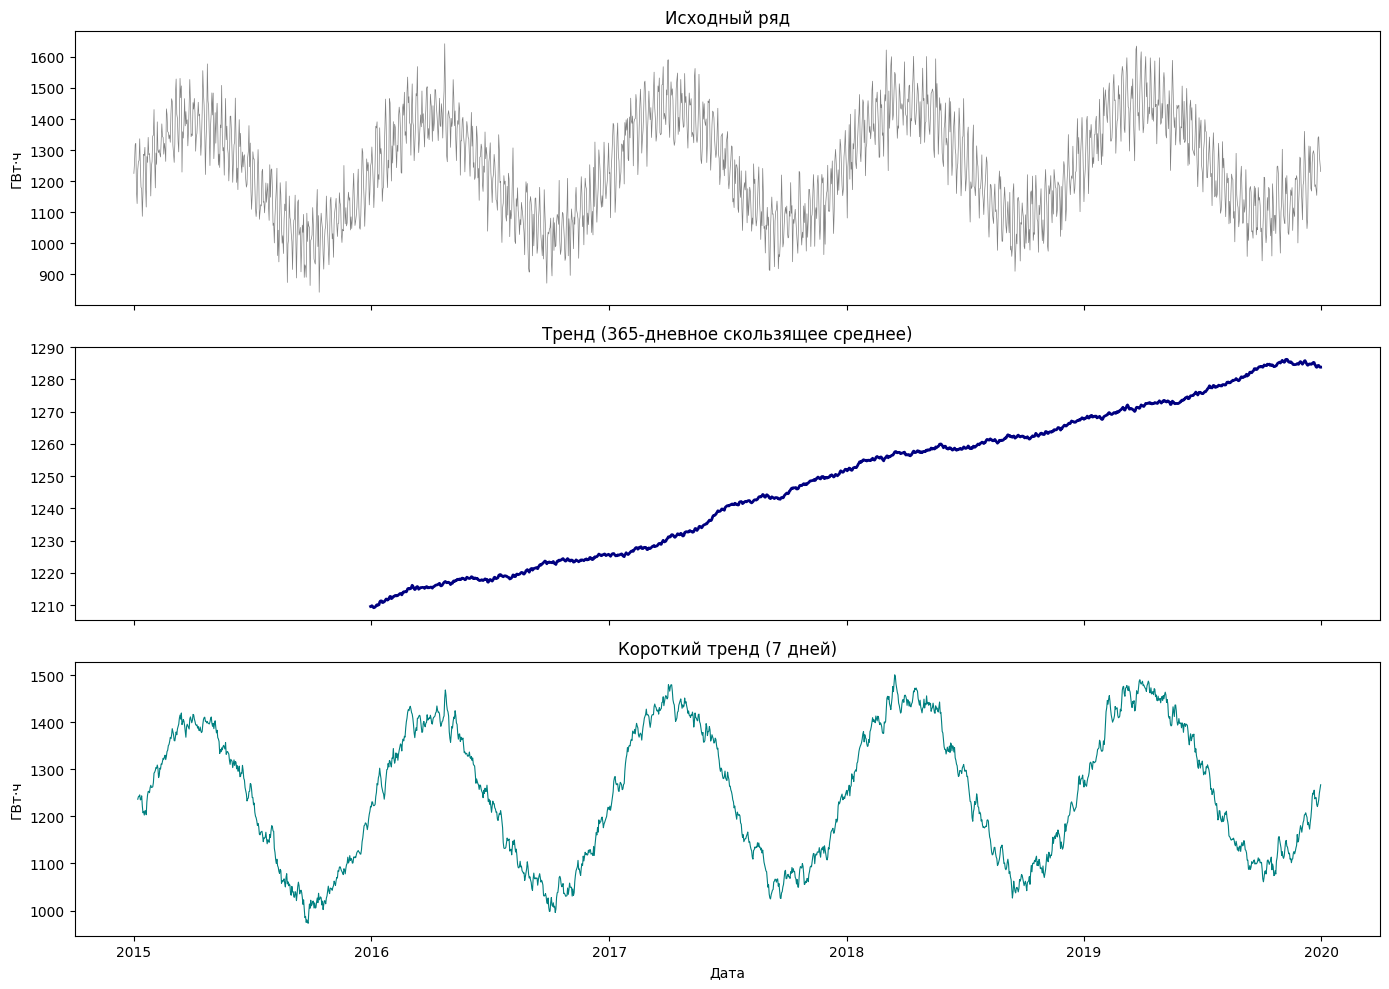

In [5]:
# БАЗОВАЯ ВИЗУАЛИЗАЦИЯ
dates_arr = df.get_column("Date").to_numpy()
cons_arr = df.get_column("Consumption").to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Исходный ряд
axes[0].plot(dates_arr, cons_arr, linewidth=0.5, color="0.5")
axes[0].set_title("Исходный ряд")
axes[0].set_ylabel("ГВт·ч")

# Тренд (365-дневное скользящее среднее)
trend_365 = df.with_columns(
    pl.col("Consumption").rolling_mean(window_size=365)
).get_column("Consumption").to_numpy()

axes[1].plot(dates_arr, trend_365, linewidth=2, color="navy")
axes[1].set_title("Тренд (365-дневное скользящее среднее)")

# Сезонность (7-дневное скользящее среднее)
trend_7 = df.with_columns(
    pl.col("Consumption").rolling_mean(window_size=7)
).get_column("Consumption").to_numpy()

axes[2].plot(dates_arr, trend_7, linewidth=0.8, color="teal")
axes[2].set_title("Короткий тренд (7 дней)")
axes[2].set_ylabel("ГВт·ч")
axes[2].set_xlabel("Дата")

plt.tight_layout()
plt.show()

In [6]:
# СОЗДАНИЕ ПРИЗНАКОВ
# все признаки строятся ТОЛЬКО из прошлого

df_feat = (
    df
    .sort("Date")
    .with_columns([
        #   Календарь
        pl.col("Date").dt.weekday().alias("dayofweek"),
        pl.col("Date").dt.month().alias("month"),
        pl.col("Date").dt.iso_year().alias("dayofyear"),
        #   Циклические (sin/cos) — чтобы модель понимала "круг"
        (2 * np.pi * pl.col("Date").dt.weekday() / 7).sin().alias("dow_sin"),
        (2 * np.pi * pl.col("Date").dt.weekday() / 7).cos().alias("dow_cos"),
        (2 * np.pi * pl.col("Date").dt.month() / 12).sin().alias("month_sin"),
        (2 * np.pi * pl.col("Date").dt.month() / 12).cos().alias("month_cos"),
        #  Лаги (значения из прошлого)
        pl.col("Consumption").shift(1).alias("lag_1"),
        pl.col("Consumption").shift(7).alias("lag_7"),
        pl.col("Consumption").shift(14).alias("lag_14"),
        #   Разности
        pl.col("Consumption").diff().alias("diff_1"),
        #   Скользящие статистики
        pl.col("Consumption").rolling_mean(window_size=7).alias("roll_mean_7"),
        pl.col("Consumption").rolling_std(window_size=7).alias("roll_std_7"),
        pl.col("Consumption").rolling_mean(window_size=30).alias("roll_mean_30"),
        #   Экспоненциальное сглаживание
        pl.col("Consumption").ewm_mean(span=7).alias("ewma_7"),
        #   Взаимодействия
        ((pl.col("Consumption") - pl.col("Consumption").rolling_mean(window_size=30))
         / (pl.col("Consumption").rolling_std(window_size=30) + 1e-8)
        ).alias("zscore_30"),
    ])
    # Отбрасываем строки с null (появились из-за lag и rolling)
    .filter(pl.col("lag_14").is_not_null())
    # Оставшиеся null заполняем нулями
    .with_columns(pl.all().exclude("Date").fill_null(0.0))
)

print(f"После создания признаков: {df_feat.shape}")

После создания признаков: (1812, 18)


In [7]:
#   РАЗДЕЛЕНИЕ TRAIN / TEST
# ВАЖНО: для временных рядов делим по дате, а не случайно!

FEATURES = [
    "dayofweek", "month", "dayofyear",
    "dow_sin", "dow_cos", "month_sin", "month_cos",
    "lag_1", "lag_7", "lag_14", "diff_1",
    "roll_mean_7", "roll_std_7", "roll_mean_30",
    "ewma_7", "zscore_30",
]
TARGET = "Consumption"

split_date = pl.date(2019, 1, 1)  # последние ~11 месяцев — тест

train = df_feat.filter(pl.col("Date") < split_date)
test  = df_feat.filter(pl.col("Date") >= split_date)

X_train = train.select(FEATURES).to_numpy()
y_train = train.get_column(TARGET).to_numpy()
X_test  = test.select(FEATURES).to_numpy()
y_test  = test.get_column(TARGET).to_numpy()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1447, 16), Test: (365, 16)


In [8]:
#  КРОСС-ВАЛИДАЦИЯ (TimeSeriesSplit)
# ВАЖНО: обычный KFold перемешивает данные — для рядов это ошибка!
# TimeSeriesSplit делает разрезы строго по времени

models = [
    ("LR", LinearRegression()),
    ("RF", RandomForestRegressor(n_estimators=100, max_depth=8,
                                 random_state=42, n_jobs=-1)),
]

print("\nКросс-валидация (5-fold TimeSeriesSplit)")
for name, model in models:
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    tscv = TimeSeriesSplit(n_splits=5)
    scores = cross_val_score(pipe, X_train, y_train, cv=tscv, scoring="r2")
    print(f"  {name}: R² = {scores.mean():.4f} ± {scores.std():.4f}")


=== Кросс-валидация (5-fold TimeSeriesSplit) ===
  LR: R² = 1.0000 ± 0.0000
  RF: R² = 0.9768 ± 0.0097



LR — прогноз
  R²:   1.0000
  MAE:  0.00
  RMSE: 0.00


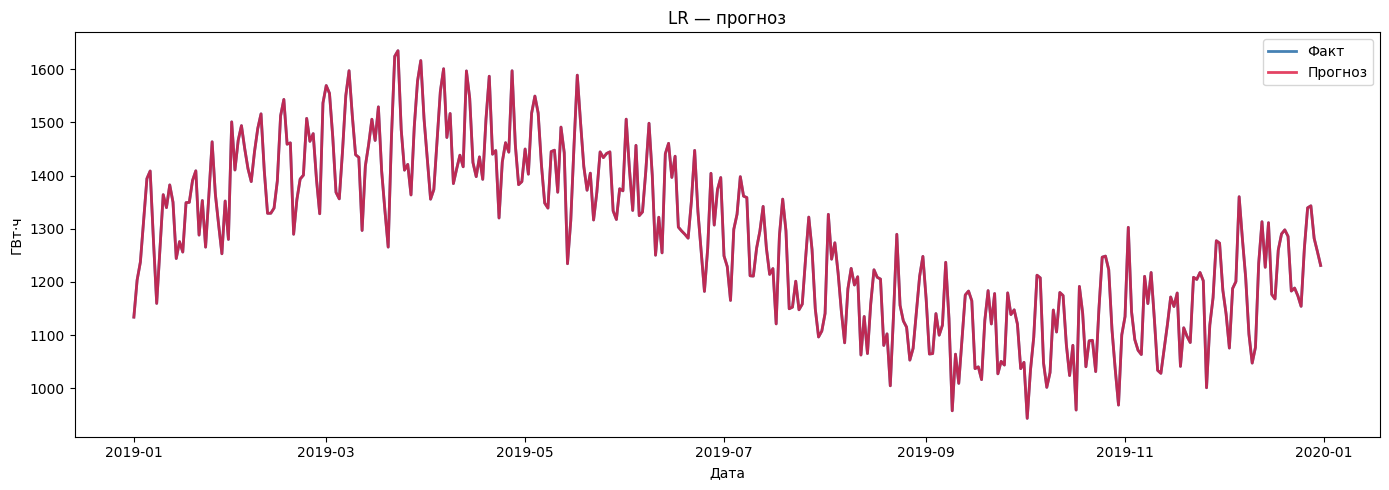


RF — прогноз
  R²:   0.9884
  MAE:  12.40
  RMSE: 16.71


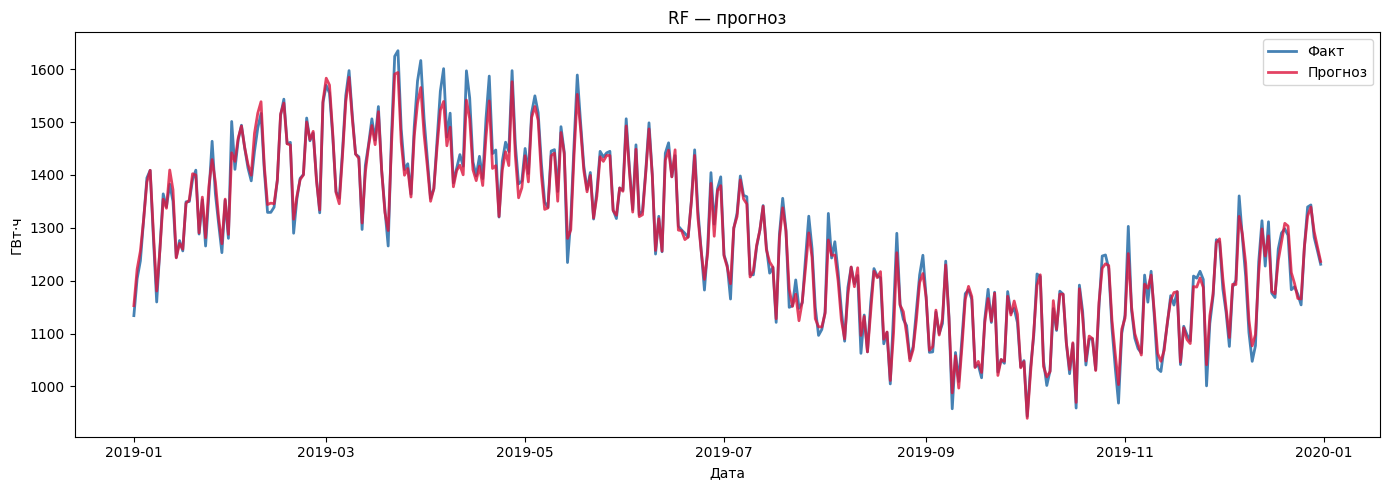

In [9]:
#   ОБУЧЕНИЕ И ПРОГНОЗ
def show_metrics(y_true, y_pred, label):
    """Выводит R², MAE, RMSE и рисует график факт vs прогноз."""
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{label}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")

    dates_test = test.get_column("Date").to_numpy()
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates_test, y_true, linewidth=2, label="Факт", color="steelblue")
    ax.plot(dates_test, y_pred, linewidth=2, label="Прогноз", color="crimson", alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel("Дата")
    ax.set_ylabel("ГВт·ч")
    ax.legend()
    plt.tight_layout()
    plt.show()

for name, model in models:
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    show_metrics(y_test, y_pred, f"{name} — прогноз")

In [10]:
print("ИТОГ:")
print("  1. Признаки из прошлого (лаги, rolling) дают R² > 0.9")
print("  2. TimeSeriesSplit — единственная правильная CV для рядов")
print("  3. Больше признаков → лучше, но важно следить за null и leakage")

ИТОГ:
  1. Признаки из прошлого (лаги, rolling) дают R² > 0.9
  2. TimeSeriesSplit — единственная правильная CV для рядов
  3. Больше признаков → лучше, но важно следить за null и leakage
